In [3]:
from hub import Hub

import pyvisgraph as vg
import openrouteservice as ors
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
from tqdm import tqdm
import rasterio as rio
from rasterio import features
import numpy as np
from skimage.graph import MCP_Geometric

from pathlib import Path
import time

In [24]:
def draw_hinterlands(
        cost_raster: str,
        hubs: list[Hub],
        id_attribute: str,
        capacity_attribute: str = "outflow",
        beta: float = 2.0
):
    """
    Returns a geopandas.GeoDataFrame of hinterland polygons for a list 
    of Hub objects via the multiplicatively weighted Voronoi diagram (MWVD) method.

    Attributes:
    - cost_raster: str
        the filepath of the raster representing travel costs
    - hubs: list[Hub]
        the list of Hub objects for which to draw hinterlands
    - capacity_attribute: str
        the name of the Hub attribute representing its capacity. Default is "outflow"\
    - beta: float
        the value of the friction coefficient. Default is 1.0
    """

    hubs_coords = []
    hubs_capacities = []

    with rio.open(cost_raster) as src:
        cost_grid = src.read(1) * 1_000 # convert values from min/m to min/km (i.e., min/pixel)
        profile = src.profile
        transform = src.transform
        bounds = src.bounds
        left, bottom, right, top = bounds

        for hub in hubs:
            # print(hub.un_locode)
            lat, lon = hub.coords
            capacity = getattr(hub, capacity_attribute)
            row, col = src.index(lon, lat)
            hubs_coords.append((row, col))
            hubs_capacities.append(capacity)
    
    # min_weighted_cost = np.full(cost_grid.shape, np.inf)
    service_area_map = np.full(cost_grid.shape, -1, dtype=np.int32)

    mcp = MCP_Geometric(cost_grid)
    export_weighted_d = None

    for i, (coord, capacity) in enumerate(zip(hubs_coords, hubs_capacities)):
        # 1. Compute least-cost distance from this Hub to all cells
        # find_costs returns cumulative cost distance 'd'
        d, _ = mcp.find_costs(starts=[coord])

        # # Manual cap on travel time
        # d_cap = np.where(d < 15, d, np.inf)

        # 2. Apply Huff-like weighting: Cost = (d^beta) / Capacity
        min_weighted_cost = np.power(np.full(cost_grid.shape, 60), beta) / np.log(capacity / 60)
        weighted_d = (np.power(d, beta)) / np.log(capacity / (d+1))
        weighted_d = np.where(d < 60, weighted_d, np.inf)

        if i == 13: # Port of Legazpi
            export_weighted_d = weighted_d.copy()

        # 3. Update the map where this Hub is the 'cheapest' option
        mask = weighted_d < min_weighted_cost
        min_weighted_cost[mask] = weighted_d[mask]
        service_area_map[mask] = i
    
    excluded_areas = service_area_map != -1

    results = (
        {"properties": {"raster_val": v}, "geometry": s}
        for i, (s, v) in enumerate(
            features.shapes(service_area_map, mask=excluded_areas, transform=transform)
        )
    )

    gdf_hinterlands = gpd.GeoDataFrame.from_features(list(results), crs="EPSG:4326")
    gdf_hinterlands["hub_id"] = gdf_hinterlands.raster_val.apply(
        lambda idx: getattr(hubs[int(idx)], id_attribute)
    )

    gdf_hinterlands = gdf_hinterlands.dissolve(by="hub_id")

    return gdf_hinterlands, export_weighted_d, bounds

In [5]:
WORK_DIR = Path().resolve().parent
DATA_DIR = WORK_DIR / "own_data"
OUTPUT_DIR = WORK_DIR / "output"

In [19]:
fp_seaports = DATA_DIR / "GmE205_SeaportData.csv"
fp_graph = DATA_DIR / "PH_SeaRouteGraph.pk1"
fp_cost = DATA_DIR / "202001_PH_Motorized_Friction_Surface_2019.tif"
fp_sea_hinterlands = OUTPUT_DIR / "PH_SeaportHinterlands.geoparquet"

In [7]:
from airport import Airport
from seaport import Seaport
from catchment import draw_isochrones, draw_hinterlands
from radiation import Radiation

In [8]:
searoute_graph = vg.VisGraph()
searoute_graph.load(fp_graph)
Seaport.set_graph(searoute_graph)

In [9]:
df_seaports = pd.read_csv(fp_seaports)
df_seaports.head()

,seaport_name,un_locode,pmo,latitude,longitude,seaport_type,n_vessels,n_passengers,year_stats
0,Port of Manila North Harbor,PHMNN,NCN,14.596667,120.954444,1,3228,776739,2024.0
1,Port of Cebu,PHCEB,CEB,10.306389,123.926111,1,78339,11858004,2025.0
2,Port of Danao,PHDNO,CEB,10.520690,124.029290,2,13114,978470,NaN
3,Port of Sta. Fe,PHSNF*,CEB,11.164890,123.805160,2,19417,1037654,NaN
4,Port of Toledo,PHTLD,CEB,10.378410,123.633870,2,11876,872091,NaN


In [10]:
seaports = []

for idx, row in df_seaports.iterrows():
    seaport = Seaport(
        name=row["seaport_name"],
        lon=row["longitude"],
        lat=row["latitude"],
        un_locode=row["un_locode"],
        pmo=row["pmo"],
        seaport_type=row["seaport_type"],
        outflow=row["n_passengers"]
    )
    seaports.append(seaport)

In [11]:
[seaport.un_locode for seaport in seaports].index("PHLEG")

13

In [25]:
gdf_seaport_catchments, weighted_d, bounds = draw_hinterlands(fp_cost, seaports, "un_locode")
gdf_seaport_catchments.head()

C:\Users\thepr\AppData\Local\Temp\ipykernel_23512\3711260741.py:57: RuntimeWarning: divide by zero encountered in log
  weighted_d = (np.power(d, beta)) / np.log(capacity / (d+1))
C:\Users\thepr\AppData\Local\Temp\ipykernel_23512\3711260741.py:57: RuntimeWarning: invalid value encountered in divide
  weighted_d = (np.power(d, beta)) / np.log(capacity / (d+1))


,geometry,raster_val
hub_id,,
PHADI*,"MULTIPOLYGON (((120.68333 13.28333, 120.68333 ...",50.0
PHAGN*,"POLYGON ((122.15 12.775, 122.15 12.76667, 122....",12.0
PHAJU,"MULTIPOLYGON (((122.90833 11.3, 122.9 11.3, 12...",87.0
PHALL*,"MULTIPOLYGON (((124.43333 12.4, 124.43333 12.3...",37.0
PHAMB*,"MULTIPOLYGON (((122.5 12.65, 122.5 12.64167, 1...",10.0


In [ ]:
np.nanpercentile(weighted_d, 0)

np.float64(0.0)

In [ ]:
weighted_d[weighted_d != np.inf].mean()

np.float64(142893703554.39532)


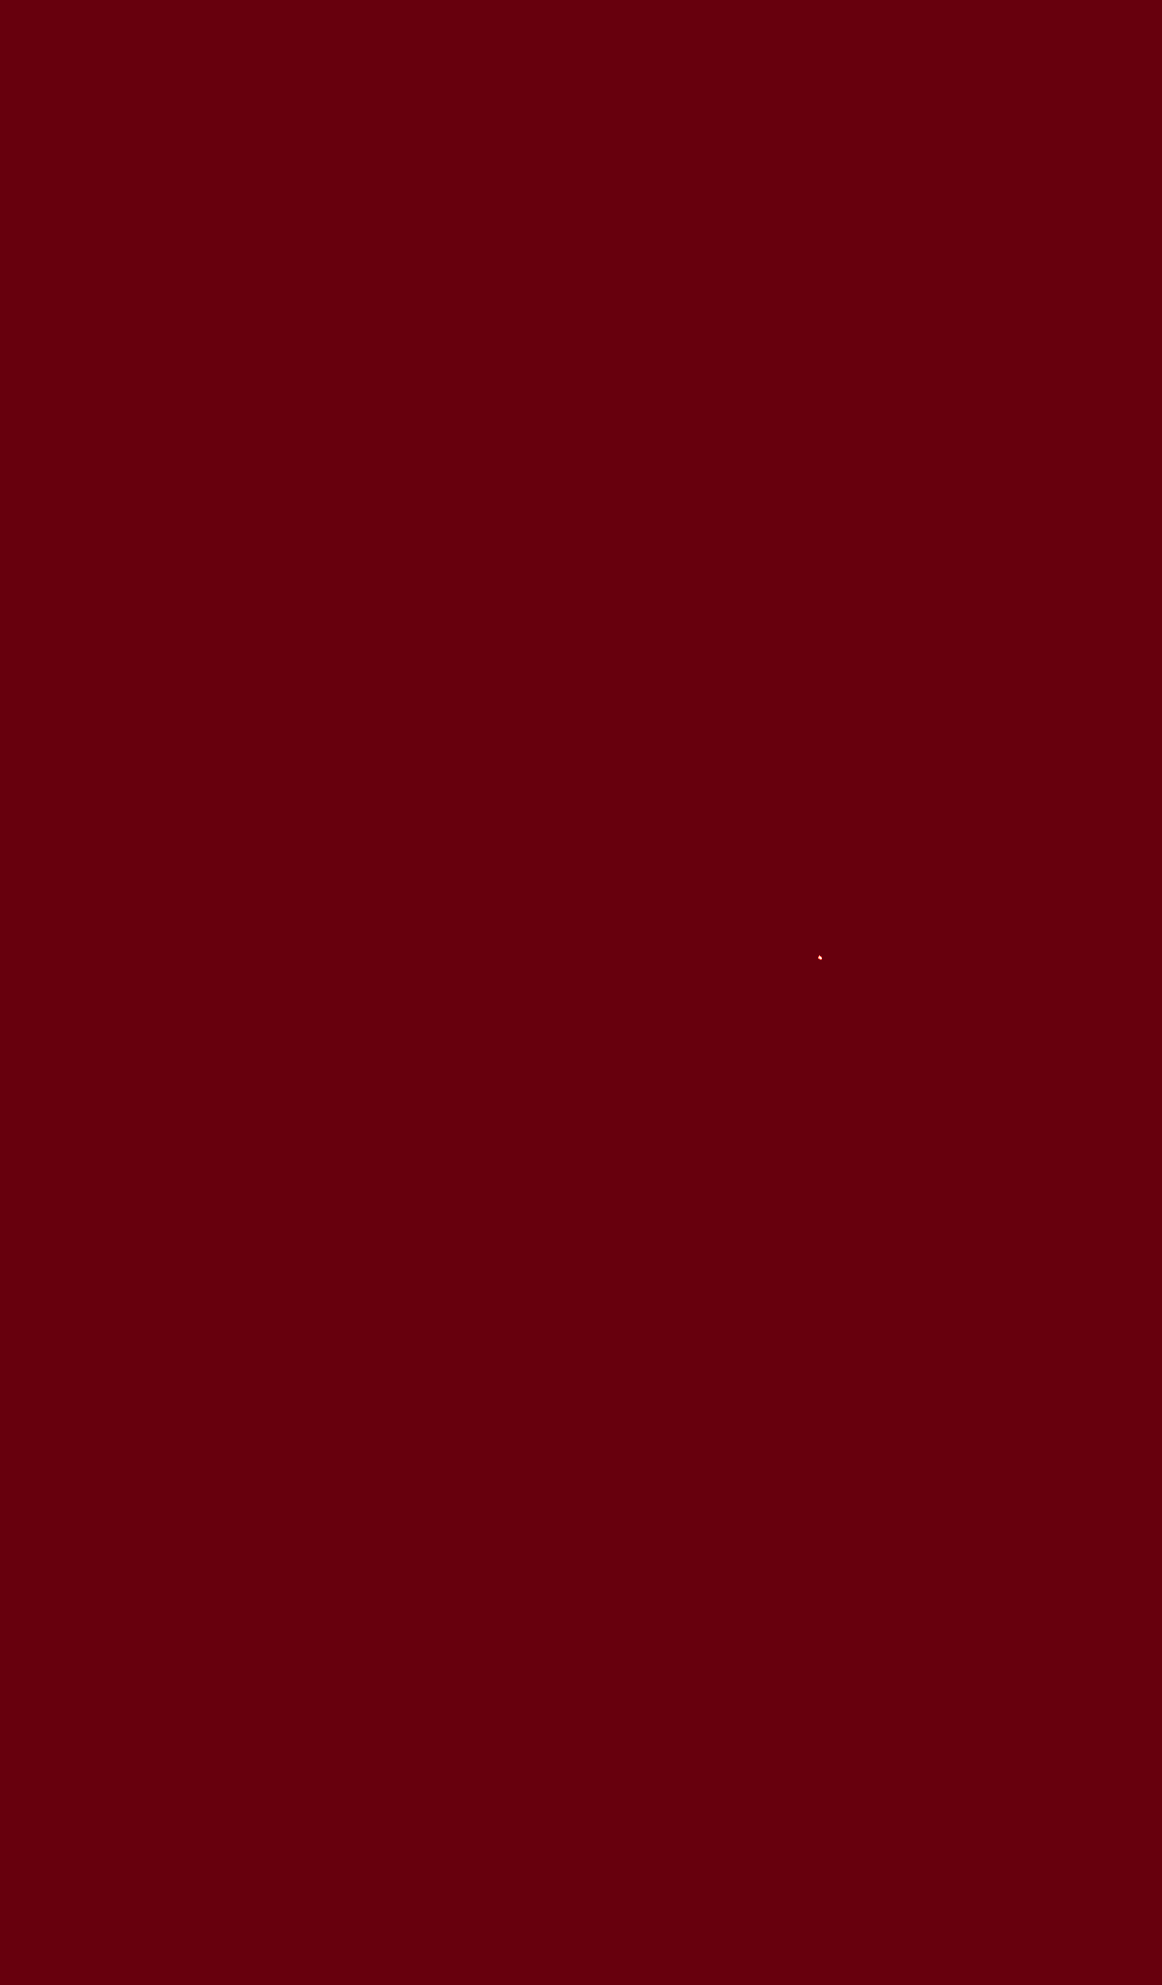

In [26]:
m = folium.Map(
    location=[(bounds[1]+bounds[3])/2, (bounds[0]+bounds[2])/2],
    zoom_start=10
)

folium.raster_layers.ImageOverlay(
    image=weighted_d,
    bounds=[[bounds[1], bounds[0]], [bounds[3], bounds[2]]],
    colormap=plt.get_cmap("Reds"),
    opacity=0.7,
    name="Weighted distance for Port of Legaspi"
).add_to(m)

gdf_seaport_catchments.explore(m=m)

In [ ]:
weighted_d

array([[inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       ...,
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf]], shape=(1985, 1480))